In [1]:
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

file_path = "wine-clustering.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "harrywang/wine-dataset-for-clustering",
    file_path,
)

print(df.head())

C:\Users\dbere\AppData\Local\Temp\ipykernel_12740\426121010.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  
0   3.92     1065  
1   3.40     1050  
2   3.17     1185  
3   3.45    

In [2]:
X = df.copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(
    eps=2.2,
    min_samples=5
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

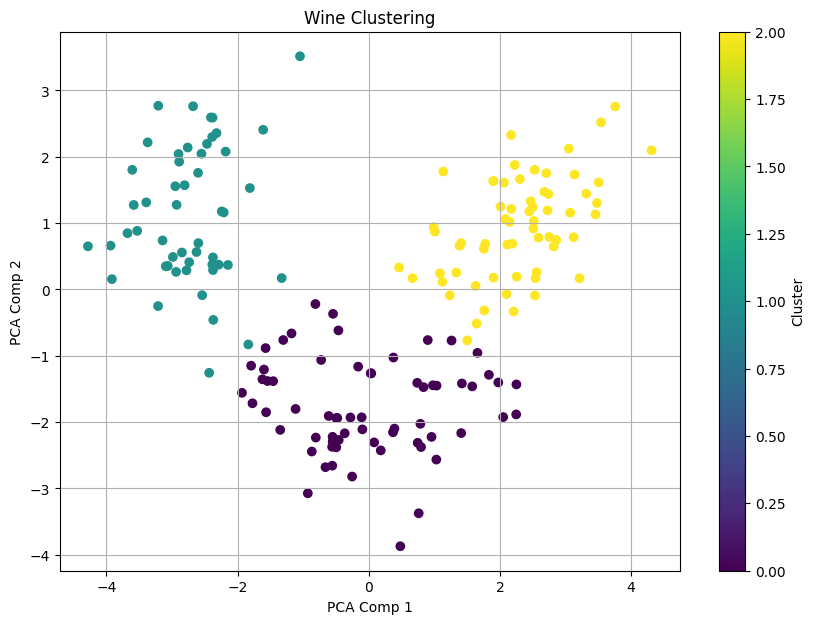

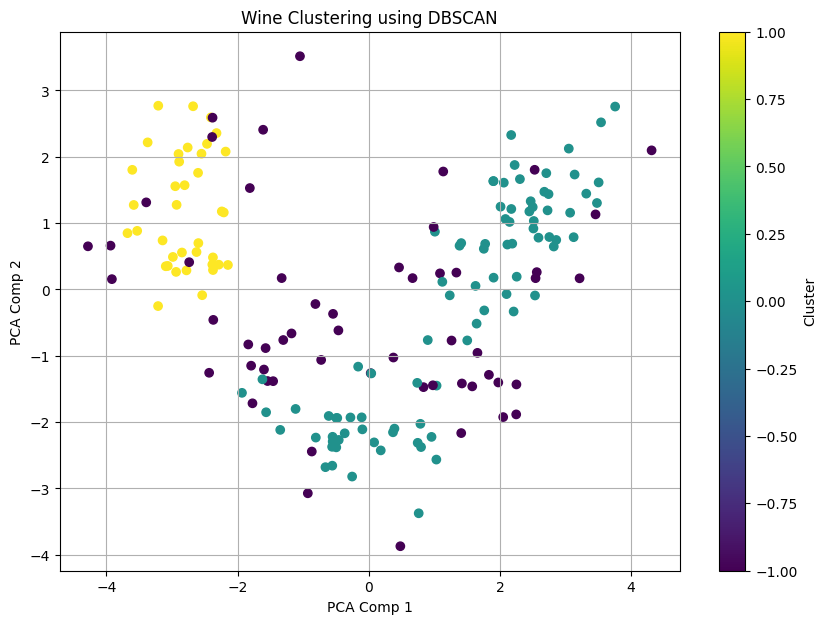

In [3]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("PCA Comp 1")
plt.ylabel("PCA Comp 2")
plt.title("Wine Clustering")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_clusters
)

plt.xlabel("PCA Comp 1")
plt.ylabel("PCA Comp 2")
plt.title("Wine Clustering using DBSCAN")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()